# Does Klinger's volume oscillator *lead* the price? 📊
### A 1970s "volume leads price" indicator, raced honestly against just buying and holding

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_price%3F: Busted](https://img.shields.io/badge/Leads_price%3F-Busted-8b949e?style=flat-square)

Here's a classic piece of charting lore. In the 1970s a trader named **Stephen Klinger** built an oscillator designed to read **volume** — the idea being that big money **accumulates** quietly (volume rises) *before* the price actually moves. Read the volume right, the story goes, and you get an **early warning**: go long when the oscillator turns positive (accumulation), step aside when it turns negative (distribution).

It sounds compelling — volume *as a leading indicator*. So we did the obvious thing: we computed Klinger's oscillator on **SPY** (the S&P 500 ETF) over **21 years**, turned it into a simple **be-long / be-flat** timing rule, and asked one blunt question: **does it beat just buying and holding?** And while we were at it: does it beat a *dead-simple* 200-day moving average?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from klinger_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    SPY = data.load_real("SPY")
    SPY = SPY[SPY.index <= ASOF]      # drop the partial current month (house rule)
else:
    SPY = None
print("real SPY cache present:", HAVE_REAL,
      "| days:", (0 if SPY is None else len(SPY)),
      "| last:", (None if SPY is None else SPY.index[-1].date()))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_days': 5385, 'fp': '63d0db58b0a8', 'k_sharpe': 0.382, 'hold_sharpe': 0.645, 'sma_sharpe': 0.776, 'macd_sharpe': 0.548, 'k_cagr': 0.037, 'hold_cagr': 0.11, 'sma_cagr': 0.085, 'k_mdd': -0.489, 'hold_mdd': -0.552, 'sma_mdd': -0.209, 'k_tim': 0.53, 'k_turn': 21.9, 't_vs_hold': -2.87, 't_vs_sma': -1.78, 't_vs_macd': -0.94, 'placebo_p': 0.669, 'placebo_median': 0.444, 'variants': [('KVO>0 long/flat', 0.382, -2.87), ('KVO>0 long/short', -0.203, -2.92), ('KVO>signal long/flat', 0.138, -4.09), ('KVO>signal long/short', -0.481, -4.14)], 'costs': [(0.0, 0.402, -2.8), (1.0, 0.382, -2.87), (2.0, 0.363, -2.95), (5.0, 0.304, -3.18)], 'panel': [('SPY', 0.382, 0.645, -2.87), ('QQQ', 0.652, 0.778, -2.65), ('IWM', 0.393, 0.47, -1.43), ('DIA', 0.394, 0.617, -2.48), ('EEM', 0.203, 0.4, -2.07), ('GLD', 0.317, 0.677, -2.96)], 'syn': [(0.0, -0.633, -0.355, -0.51, 0.981), (3.0, 5.613, 0.439, 8.21, 0.0)]}


real SPY cache present: True | days: 5385 | last: 2026-05-29


## The answer first

| Question | Answer |
|---|---|
| Does timing SPY with Klinger beat buy-and-hold? | **No.** Over 21 years its risk-adjusted return (Sharpe **0.38**) is *worse* than simply holding (**0.65**) — and the gap is statistically real (it's reliably behind). |
| Does it beat a dumb 200-day moving average? | **No.** A one-line trend filter scores Sharpe **0.78** with **far** less trading. Klinger trades ~22× a year and still loses the race. |
| Is the *timing* any good at all? | **No.** A **random** schedule that's long the same fraction of days beats Klinger's actual timing **67%** of the time. When it's long isn't informative. |
| So does volume "lead price" here? | **Not in any tradable way.** The oscillator reacts to volume that has *already* happened; it doesn't anticipate the next move. |

> The legend is **busted** on the tape: Klinger's oscillator is a fine *description* of past volume, but as a *leading* timing signal on the index it adds nothing — and costs you the trading.

## 1 · The claim

> *"Volume precedes price. Klinger's oscillator measures the long-term force of **accumulation** versus **distribution** by weighting each day's volume by its trend and range. When the oscillator is **positive**, smart money is accumulating — ride it. When it turns **negative**, they're distributing — get out. Because it reads volume, it **leads** the price."*

Stephen Klinger published the **Klinger Volume Oscillator** in *Technical Analysis of Stocks & Commodities* (1997). It's a staple in charting packages (TradingView, StockCharts). The selling point is exactly the *leading* property: catch the turn before the crowd. So the question is simple — **does the volume actually lead, or does the oscillator just lag the price like everything else?**

## 2 · So what?

If a volume oscillator truly **led** price, that would be a real crack in efficiency: you could see the move coming in the order flow before it showed up in the close. A reliable be-long/be-flat switch on the S&P that **beat buy-and-hold** would be worth a fortune — you'd capture the upside and dodge the crashes.

But there's a trap that kills most timing indicators: **buying and holding is a very high bar.** The market drifts up most of the time, so any rule that sits in cash part of the year gives up that drift — and has to *more than* make it back by dodging the bad days. And it has to do that **net of the trading costs** it racks up flipping in and out. We'll hold Klinger to that bar.

## 3 · How would we even know?

We take **21 years** of daily SPY (2005-01-03 → 2026-05-29), compute Klinger's oscillator, and make the simplest honest rule:

1. **The rule.** Oscillator **above zero** → be **long** SPY. Below zero → be **flat** (in cash). Signal read at today's close, position taken **tomorrow** (no peeking).
2. **The race.** Compare its risk-adjusted return (Sharpe) — *after* trading costs — to **buy-and-hold**, and to a **200-day moving-average** rule and **MACD** (the obvious simpler competitors).
3. **The luck check.** Shuffle *when* the rule is long into a random schedule with the same time-in-market. If Klinger's *timing* is informative, the real rule should beat the random schedules. **If a coin does as well, the signal is noise.**

What would make us say *mirage*? If Klinger doesn't clear buy-and-hold, gets beaten by the one-line moving average, and can't beat a random schedule — three strikes.

## 4 · The teardown — let's actually look

**First, the headline race.** Growth of \$1 (excess of cash) for buy-and-hold, the Klinger long/flat rule, and the dumb 200-day moving average. If volume "leads price," the green Klinger line should pull ahead.

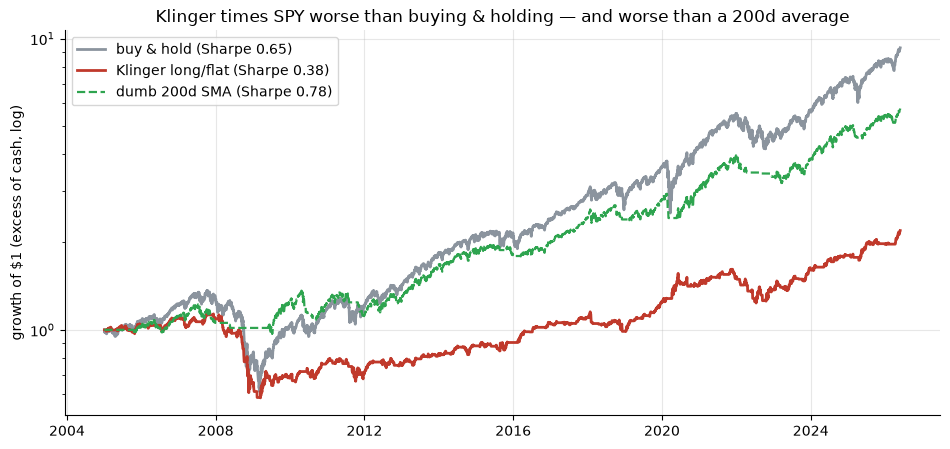

Klinger Sharpe 0.38  vs  buy-hold 0.65  vs  200d SMA 0.78


In [2]:
if HAVE_REAL:
    kpos = st.klinger_position(SPY, mode='zero')
    spos = st.sma_position(SPY)
    kb = st.book_returns(SPY, kpos, cost_bps=1.0)
    sb = st.book_returns(SPY, spos, cost_bps=1.0)
    eq_hold = (1+kb['asset_excess']).cumprod()
    eq_k = (1+kb['strat_excess']).cumprod()
    eq_s = (1+sb['strat_excess']).cumprod()
    idx = SPY.index
else:
    idx = pd.bdate_range('2005-01-03', periods=R['n_days'])
    eq_hold = pd.Series(np.linspace(1, np.exp(R['hold_cagr']*R['years']), R['n_days']), index=idx)
    eq_k = pd.Series(np.linspace(1, np.exp(R['k_cagr']*R['years']), R['n_days']), index=idx)
    eq_s = pd.Series(np.linspace(1, np.exp(R['sma_cagr']*R['years']), R['n_days']), index=idx)
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.plot(idx, eq_hold, c=GREY, lw=2, label=f'buy & hold (Sharpe {R["hold_sharpe"]:.2f})')
ax.plot(idx, eq_k, c=RED, lw=2, label=f'Klinger long/flat (Sharpe {R["k_sharpe"]:.2f})')
ax.plot(idx, eq_s, c=GREEN, lw=1.6, ls='--', label=f'dumb 200d SMA (Sharpe {R["sma_sharpe"]:.2f})')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (excess of cash, log)')
ax.set_title('Klinger times SPY worse than buying & holding — and worse than a 200d average')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Klinger Sharpe {R["k_sharpe"]:.2f}  vs  buy-hold {R["hold_sharpe"]:.2f}  vs  200d SMA {R["sma_sharpe"]:.2f}')

The red Klinger line **lags** the grey buy-and-hold line, and the dashed green 200-day-average line — about as dumb a trend rule as exists — **beats both**. Klinger's Sharpe is **0.38** against buy-and-hold's **0.65**. The "leading" indicator is *behind*.

**Is the timing informative at all?** Here's the honest luck test. Klinger is long ~53% of days. We shuffle *when* it's long into thousands of **random** schedules with the same time-in-market, and plot the Sharpe each random schedule earns. If Klinger's timing means anything, the real line should sit in the **right tail**.

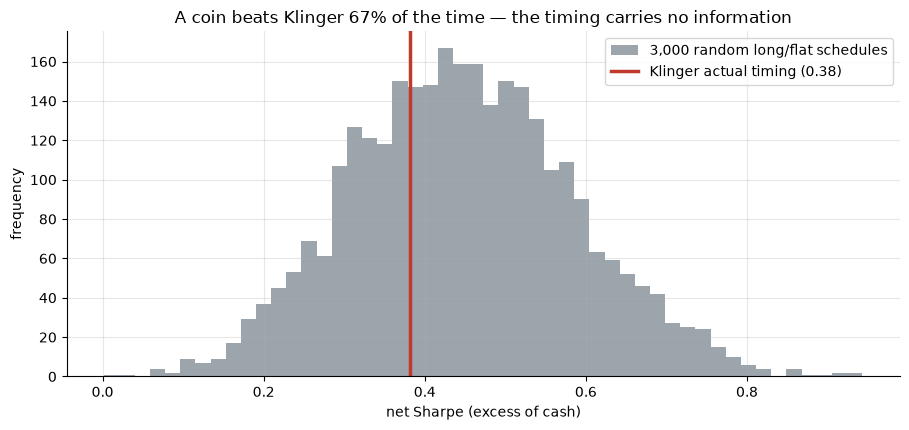

Klinger 0.38  |  random-schedule median 0.44  |  p(random >= Klinger) = 0.669


In [3]:
if HAVE_REAL:
    pl = st.block_permutation_p(kb, n_draws=3000, seed=430)
    draws = pl['draws']; obs = pl['obs_sharpe']; pval = pl['p_value']
else:
    rng = np.random.default_rng(430); draws = rng.normal(R['placebo_median'], 0.18, 3000)
    obs = R['k_sharpe']; pval = R['placebo_p']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='3,000 random long/flat schedules')
ax.axvline(obs, c=RED, lw=2.5, label=f'Klinger actual timing ({obs:.2f})')
ax.set_xlabel('net Sharpe (excess of cash)'); ax.set_ylabel('frequency')
ax.set_title(f'A coin beats Klinger {pval*100:.0f}% of the time — the timing carries no information')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Klinger {obs:.2f}  |  random-schedule median {np.median(draws):.2f}  |  p(random >= Klinger) = {pval:.3f}')

The red line sits **left of the middle** of the random cloud: a random schedule beats Klinger's actual timing **67%** of the time, and the *typical* coin (median Sharpe **0.44**) does **better** than Klinger (**0.38**). Knowing *when* the oscillator is positive tells you nothing useful about the next day.

## 5 · The verdict

- **Signal — None.** Klinger's long/flat rule on SPY scores Sharpe **0.38**, *below* buy-and-hold (**0.65**) and below a one-line 200-day average (**0.78**). The difference vs buy-and-hold is significant — significantly **worse** (*t* ≈ −2.9). A random schedule beats its timing two-thirds of the time.
- **Tradability — Mirage.** It loses the race *and* trades ~22× a year; costs only widen the gap. There is no edge to deploy.
- **"Volume leads price"? — Busted.** The oscillator reacts to volume that already printed; on the index it does not anticipate the move.

## 6 · Could you actually trade it? — costs only make it worse

There's nothing to rescue with cheaper execution: Klinger is already *behind* before costs. Here's its Sharpe as we charge more per trade — it just slides further from the buy-and-hold line it never reached.

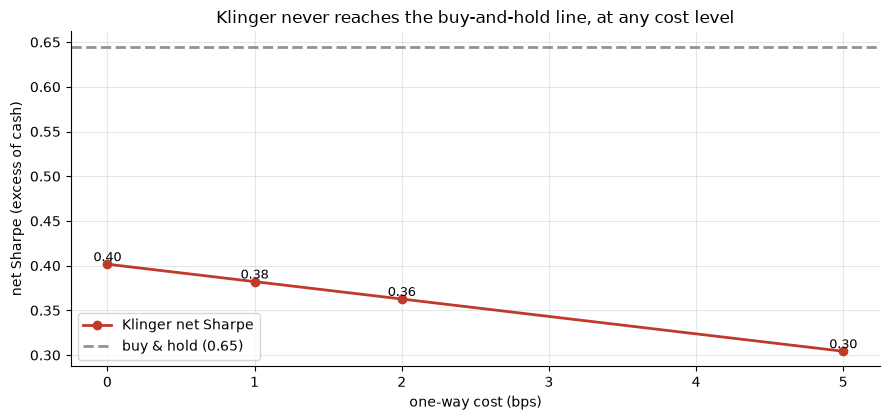

cost sweep (bps -> Sharpe): {0.0: 0.402, 1.0: 0.382, 2.0: 0.363, 5.0: 0.304}


In [4]:
cb = [c[0] for c in R['costs']]
if HAVE_REAL:
    shp = [st.run_experiment(SPY, mode='zero', cost_bps=c, with_placebo=False)['klinger']['sharpe'] for c in cb]
else:
    shp = [c[1] for c in R['costs']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(cb, shp, 'o-', c=RED, lw=2, label='Klinger net Sharpe')
ax.axhline(R['hold_sharpe'], c=GREY, ls='--', lw=2, label=f'buy & hold ({R["hold_sharpe"]:.2f})')
for x,y in zip(cb,shp): ax.annotate(f'{y:.2f}',(x,y),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe (excess of cash)')
ax.set_title('Klinger never reaches the buy-and-hold line, at any cost level')
ax.legend(); plt.tight_layout(); plt.show()
print('cost sweep (bps -> Sharpe):', {c:round(s,3) for c,s in zip(cb,shp)})

Even at **zero cost** Klinger lands at Sharpe ~0.40 — still under buy-and-hold's 0.65. The problem isn't friction; it's that the signal doesn't add information. Costs are just salt in the wound.

## 7 · Going further 🚪

- **Other parameters.** We used Klinger's standard (34, 55, 13). The quants notebook shows the *signal-line* variant and the long/short variant — both are **worse**, not better.
- **Other markets.** We ran a 6-ETF panel (SPY/QQQ/IWM/DIA/EEM/GLD). Klinger loses to buy-and-hold on **every one**.
- **The honest lesson.** "Volume leads price" is a seductive story, but a volume oscillator is still a **moving average of the past**. Lagging averages can't lead. If you think a different Klinger parameter set beats buy-and-hold net of costs on SPY — fork it and show the green line on top.